<a href="https://colab.research.google.com/github/Omkarmali2236/AIML-projects/blob/main/final_ENGINE_HEALTH_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q pandas numpy scikit-learn imbalanced-learn joblib matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Here we load the dataset

DATA_PATH = "/content/engine_data.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset Loaded")
print(df.head())

# Data preprocessing

df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

# Detect target column automatically
possible_targets = [c for c in df.columns if "fault" in c.lower() or
                    "status" in c.lower() or "health" in c.lower() or
                    "label" in c.lower()]

if len(possible_targets) > 0:
    target = possible_targets[0]
else:
    target = df.columns[-1]

print("Target Column:", target)

X = df.drop(target, axis=1)
y = df[target]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle imbalance if present
sm = SMOTE()
X_res, y_res = sm.fit_resample(X_scaled, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Traing models

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies[name] = acc
    print("\nModel:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))

# Select best model based on accuracy

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])

# Save best model
joblib.dump(best_model, "engine_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully as engine_model.pkl")

# Prediction Function (Engine Good or Faulty)

def predict_engine_status(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    scaled = scaler.transform(input_df)
    prediction = best_model.predict(scaled)[0]
    return prediction

# Example prediction format (you must enter real sensor values)
print("\nExample Prediction:")
example_input = list(X.iloc[0])   # using first row's features
print("Output:", predict_engine_status(example_input))
result = predict_engine_status(example_input)
if result == 1:
    print("Engine Status: FAULTY")
else:
    print("Engine Status: GOOD")



Dataset Loaded
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         700          2.493592      11.790927          3.178981   
1         876          2.941606      16.193866          2.464504   
2         520          2.961746       6.553147          1.064347   
3         473          3.707835      19.510172          3.727455   
4         619          5.672919      15.738871          2.052251   

   lub oil temp  Coolant temp  Engine Condition  
0     84.144163     81.632187                 1  
1     77.640934     82.445724                 0  
2     77.752266     79.645777                 1  
3     74.129907     71.774629                 1  
4     78.396989     87.000225                 0  
Target Column: Engine Condition

Model: Logistic Regression
Accuracy: 0.6500913334686422
              precision    recall  f1-score   support

           0       0.66      0.62      0.64      2448
           1       0.64      0.68      0.66      2479

    accuracy           

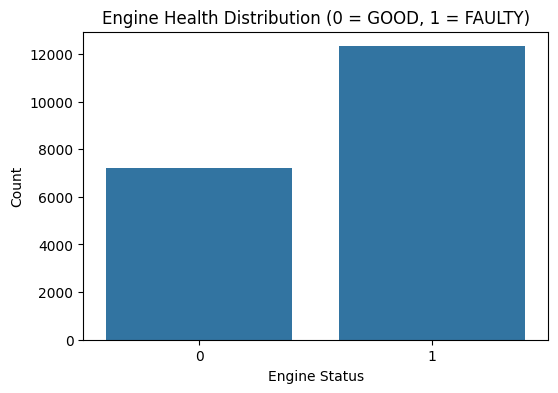

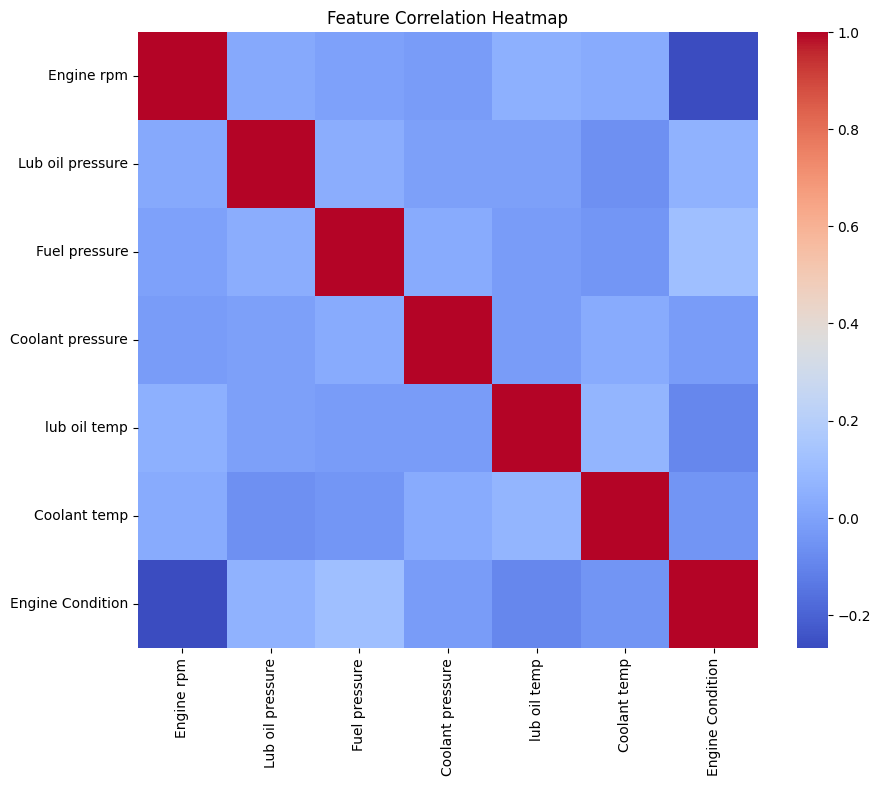

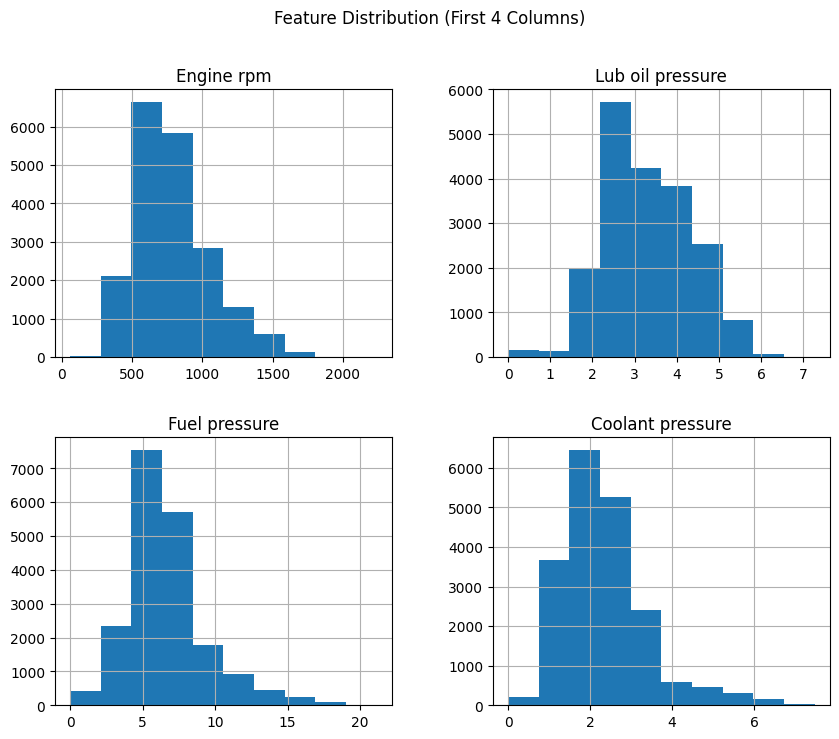

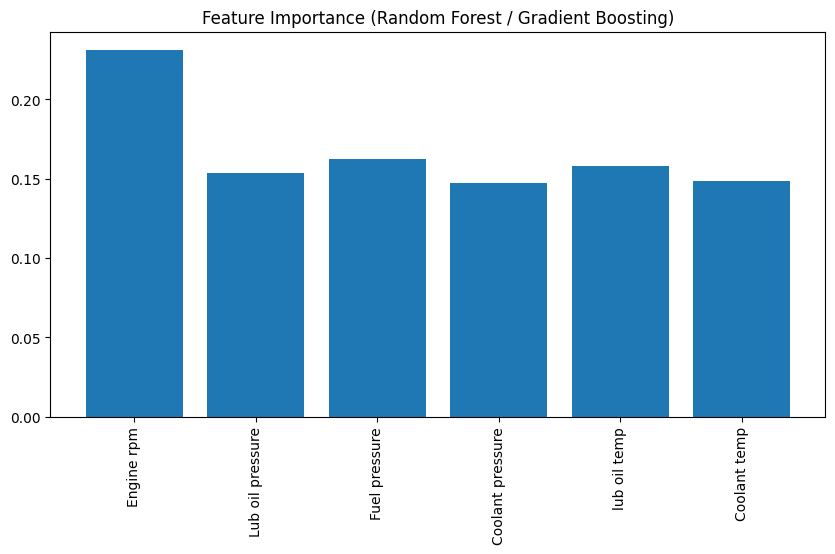

In [5]:
# Visualization (Plots for Engine Analysis)
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Engine Health Distribution (0 = GOOD, 1 = FAULTY)")
plt.xlabel("Engine Status")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature distribution plots (first 4 features)
df.iloc[:, :4].hist(figsize=(10,8))
plt.suptitle("Feature Distribution (First 4 Columns)")
plt.show()

# Feature importance if model supports it
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feature_names = X.columns

    plt.figure(figsize=(10,5))
    plt.bar(feature_names, importances)
    plt.xticks(rotation=90)
    plt.title("Feature Importance (Random Forest / Gradient Boosting)")
    plt.show()